# 08 — Donor-level vs. within-donor regional CPS association

`CPS_Global` (constant within a donor) and `CPS_Local` (constant within a donor x
region) get modelled together here as two separate regressors -- `global_cps_z` for
between-donor disease burden and `local_within_z` (`CPS_Local` centered on that donor's
own mean across its observed regions) for within-donor regional excess pathology. This
cleanly separates "this donor is sicker overall" from "this region is worse than this
donor's other regions", which neither `04_progression.ipynb`'s `mixed_model_trend`
(one CPS variant at a time) nor `05_mixed_models.ipynb`'s `test_factor`
(`CPS_Local` alone) does.

**Data**: `03_pseudobulk.ipynb`'s `activity.parquet`/`meta.parquet` (donor x region
units, already pruned to the live, non-vanished directions). This notebook does not
modify `03_pseudobulk.ipynb`, `04_progression.ipynb`, or `05_mixed_models.ipynb`.


In [1]:
from __future__ import annotations

import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from joblib import Parallel, delayed
from scipy import stats
from scipy.stats import chi2
from sklearn.model_selection import GroupKFold
from statsmodels.regression.linear_model import OLS
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.stats.outliers_influence import variance_inflation_factor

import sst_drvi as S

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_rows", 140)

PSEUDO_DIR = S.SCRATCH / "pseudobulk"


In [2]:
# FDR and practical-effect thresholds for the "supported" calls that gate sections 3-6.
Q_THRESHOLD = 0.05
EFFECT_THRESHOLD = 0.10

# Cluster-bootstrap resamples per direction and bounded parallelism for section 6, which
# refits models 124 x N_BOOT and 124 x n_donors times -- this machine has 16 cores.
N_BOOT = 200
N_JOBS = 8
RANDOM_STATE = 0


## Helpers used more than once

`donor_level_standardize` z-scores a donor-level covariate from one row per donor (not
one row per donor x region unit), so a donor observed in 10 regions doesn't get 10x the
weight of a donor observed in 1 region when setting the standardization mean/SD; it is
used for `global_cps_z`, `age_z`, `pmi_z`, and the ABeta/pTau global CPS variants in
section 5. `fit_direction` wraps a single `mixedlm` fit with warnings suppressed exactly
as `04_progression.ipynb`'s `mixed_model_trend` does; every fitting call below goes
through it with `method="powell"` regardless of `reml`. `04_progression.ipynb` already
documents `lbfgs` landing many `reml=True` fits on the zero-variance donor boundary;
checked directly here, the same collapse happens with `reml=False` too -- on every one
of the 24 real `supported_global` directions, `lbfgs` reported `donor_sd=0` and an
infinite log-likelihood for the region-interaction model in section 3, and the same
collapse reproduces on the plain primary formula used by the section-6 bootstrap and
leave-one-donor-out refits. `powell` (cross-checked against `cg`/`bfgs`/`nm`, which
agree closely) is used everywhere below instead of `05_mixed_models.ipynb`'s `lbfgs`,
at roughly 3.5x the per-fit cost. `bh_correct` and `lrt` are the same scipy-based FDR
convention and nested-model LRT those two notebooks already use (`lrt` returns NaN
rather than warning when a fit's log-likelihood isn't finite, so a failed fit is
dropped by `bh_correct` rather than crashing the loop). `linear_contrast` builds the
raw contrast vector `MixedLMResults.t_test` requires (it has no formula-string
support). `volcano_plot` draws one effect's beta vs. -log10(q) scatter with the same
threshold lines and supported/not-supported styling; it is called once for
`local_within` and once for `global_cps` right after section 2's primary fit.
Everything else below is written out at the point of use.


In [3]:
def donor_level_standardize(df: pd.DataFrame, col: str, donor_col: str = "donor") -> pd.Series:
    '''Z-score a donor-constant column using one row per donor.

    A donor observed in many regions must not get proportionally more weight than a
    donor observed in one when setting the standardization mean/SD -- dedupe to one row
    per donor, compute mean/std there, then broadcast back to every row of that donor.
    '''
    donor_values = df.groupby(donor_col)[col].first()
    mean, std = donor_values.mean(), donor_values.std()
    return (df[col] - mean) / std


def fit_direction(frame: pd.DataFrame, formula: str, reml: bool, method: str):
    '''One ``mixedlm(formula, frame, groups=frame["donor"])`` fit, warnings suppressed.'''
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return smf.mixedlm(formula, frame, groups=frame["donor"]).fit(method=method, reml=reml)


def bh_correct(pvalues: np.ndarray) -> np.ndarray:
    '''Benjamini-Hochberg over the finite p-values only; NaN elsewhere.

    scipy rejects a NaN p-value outright rather than passing it through, and a fit that
    failed should not shift everyone else's threshold by counting toward the number of
    tests.
    '''
    q = np.full(len(pvalues), np.nan, dtype=float)
    usable = np.isfinite(pvalues)
    if usable.any():
        q[usable] = stats.false_discovery_control(pvalues[usable], method="bh")
    return q


def lrt(reduced_fit, full_fit) -> tuple[float, int, float]:
    '''Likelihood-ratio test between two nested ``mixedlm`` fits (both ``reml=False``).

    A fit that failed to converge can come back with a non-finite ``llf``; report the
    test as NaN rather than letting a NaN propagate through ``max()`` with a warning --
    ``bh_correct`` already treats a NaN p-value as an unusable test, not a zero.
    '''
    lr_df = len(full_fit.fe_params) - len(reduced_fit.fe_params)
    if not (np.isfinite(full_fit.llf) and np.isfinite(reduced_fit.llf)):
        return np.nan, lr_df, np.nan
    lr_stat = max(0.0, 2 * (full_fit.llf - reduced_fit.llf))
    return lr_stat, lr_df, chi2.sf(lr_stat, lr_df)


def linear_contrast(fit, positive: str, negative: str):
    '''``t_test`` for ``positive - negative`` on a fitted ``mixedlm``.

    ``MixedLMResults.t_test`` takes a raw contrast vector over fixed effects only (no
    formula-string support the way ``OLSResults.t_test`` has), so build one aligned to
    ``fit.fe_params.index`` by hand; used for both the pTau-vs-ABeta contrasts in
    section 5.
    '''
    names = list(fit.fe_params.index)
    vec = np.zeros((1, len(names)))
    vec[0, names.index(positive)] = 1.0
    vec[0, names.index(negative)] = -1.0
    return fit.t_test(vec)


def volcano_plot(ax, table: pd.DataFrame, beta_col: str, q_col: str, supported_col: str, label: str) -> None:
    '''Effect size vs. -log10(q) for one CPS effect, called once per effect in section 2.

    Significance is read off ``q`` (not raw ``p``), so the horizontal threshold line is
    directly the FDR cutoff that defines ``supported_col``; NaN q (a fit that failed to
    converge) is dropped rather than plotted at a misleading y position. Supported points
    get both a distinct color and a distinct marker, not color alone.
    '''
    q = table[q_col].to_numpy(float)
    finite = np.isfinite(q)
    neg_log10_q = np.full(len(table), np.nan)
    neg_log10_q[finite] = -np.log10(np.clip(q[finite], 1e-300, None))
    supported = table[supported_col].to_numpy(bool) & finite

    ax.scatter(
        table.loc[~supported & finite, beta_col], neg_log10_q[~supported & finite],
        s=14, marker="o", facecolors="none", edgecolors="0.6", linewidths=0.7,
        label="not supported",
    )
    ax.scatter(
        table.loc[supported, beta_col], neg_log10_q[supported],
        s=28, marker="D", color="#d55e00", linewidths=0, label="supported",
    )
    ax.axhline(-np.log10(Q_THRESHOLD), color="0.4", linestyle="--", linewidth=1)
    ax.axvline(EFFECT_THRESHOLD, color="0.4", linestyle=":", linewidth=1)
    ax.axvline(-EFFECT_THRESHOLD, color="0.4", linestyle=":", linewidth=1)
    ax.set_xlabel(f"standardized {label} slope (beta)")
    ax.set_ylabel(r"$-\log_{10}(q)$")
    ax.set_title(f"{label}: {int(supported.sum())}/{finite.sum()} supported")

    for _, row in table.loc[supported].nsmallest(8, q_col).iterrows():
        ax.annotate(
            row["direction"], (row[beta_col], -np.log10(max(row[q_col], 1e-300))),
            fontsize=7, xytext=(3, 3), textcoords="offset points",
        )


def forest_plot(ax, regional_df: pd.DataFrame, direction: str, label: str) -> None:
    '''Per-region beta +/- 95% CI for one direction, called once per plotted direction in
    section 3's heterogeneity forest plots (local and global).
    '''
    d = regional_df.loc[regional_df["direction"] == direction].sort_values("beta")
    y = np.arange(len(d))
    ax.errorbar(
        d["beta"], y, xerr=[d["beta"] - d["ci_low"], d["ci_high"] - d["beta"]],
        fmt="D", color="#0072b2", ecolor="0.5", capsize=3, markersize=5,
    )
    ax.axvline(0, color="0.5", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(d["region"])
    ax.set_xlabel(f"{label} slope")
    ax.set_title(direction, fontsize=9)


## 1 — Data assembly

Section 1 measures the granularity and builds one donor x region cohort shared by every
section below -- the same analytic cohort is used for every direction, per the design's
requirement.


In [4]:
activity = pd.read_parquet(PSEUDO_DIR / "activity.parquet")
meta = pd.read_parquet(PSEUDO_DIR / "meta.parquet")
directions = list(activity.columns)
print(f"{len(directions)} live directions x {activity.shape[0]} donor x region units")


124 live directions x 516 donor x region units


In [5]:
# APOE genotype is not yet carried into meta.parquet (only Sex/Age at Death/PMI are).
# Rather than touch 03_pseudobulk.ipynb's carry list -- which 04/05 also depend on --
# pull a donor x genotype lookup straight from the embedding's obs (a metadata-only
# read; backed mode avoids loading the full latent matrix for this).
CANDIDATES = ["sst_k64_covar_long", "sst_k64_covar", "sst_k64"]
MODEL = "drvi"

RUN = None
for candidate in CANDIDATES:
    embed_path = S.EMBED_DIR / f"{candidate}_{MODEL}_embed.h5ad"
    if embed_path.exists():
        RUN = candidate
        break
    print(f"{candidate} not on disk")
if RUN is None:
    raise FileNotFoundError(f"no DRVI embedding found among {CANDIDATES}")

embed_obs = ad.read_h5ad(embed_path, backed="r").obs
apoe = (
    embed_obs[["Donor ID", "APOE Genotype"]]
    .drop_duplicates("Donor ID")
    .set_index("Donor ID")["APOE Genotype"]
)
print(f"run: {RUN}; APOE genotype known for {apoe.notna().sum()}/{len(apoe)} donors")


run: sst_k64_covar_long; APOE genotype known for 84/84 donors


In [6]:
# Keep the donor x region MultiIndex throughout so `df`/`cohort` share rows with
# `activity` -- no merge needed when a direction's values are pulled in per-loop below.
df = meta.copy()
df["donor"] = df.index.get_level_values("Donor ID").astype(str)
df["region"] = df.index.get_level_values("Brain Region").astype(str)
df["sex"] = df["Sex"].astype(str)
df["age"] = pd.to_numeric(df["Age at Death"], errors="coerce")
df["pmi"] = pd.to_numeric(df["PMI"], errors="coerce")

genotype = df["donor"].map(apoe)
df["apoe_e4"] = genotype.str.contains("4").astype(float)
df["apoe_e2"] = genotype.str.contains("2").astype(float)

# Within-donor regional excess: CPS_Local minus that donor's own mean across its
# observed regions. Exactly 0 for a donor seen in only one region -- informative for the
# global slope below, structurally uninformative for the local slope, no special-casing
# needed to exclude them.
df["local_mean"] = df.groupby("donor")["CPS_Local"].transform("mean")
df["local_within"] = df["CPS_Local"] - df["local_mean"]

df["local_within_z"] = (df["local_within"] - df["local_within"].mean()) / df["local_within"].std()
df["global_cps_z"] = donor_level_standardize(df, "CPS_Global")
df["age_z"] = donor_level_standardize(df, "age")
df["pmi_z"] = donor_level_standardize(df, "pmi")


In [7]:
# The spec's checks before treating local_mean as a candidate sensitivity regressor
# (never included alongside CPS_Local/local_within -- that would duplicate information).
donor_level = df.drop_duplicates("donor")
corr_local_mean_global = donor_level[["local_mean", "CPS_Global"]].corr().iloc[0, 1]

regions_per_donor = df.groupby("donor").size()
n_single_region = int((regions_per_donor == 1).sum())

print(f"corr(local_mean, CPS_Global) across {len(donor_level)} donors: {corr_local_mean_global:.3f}")
print(f"{n_single_region} donor(s) observed in only one region "
      "(local_within is exactly 0 for these; they still inform the global slope)")
print("regions observed per donor:")
print(regions_per_donor.describe())


corr(local_mean, CPS_Global) across 84 donors: 0.988
1 donor(s) observed in only one region (local_within is exactly 0 for these; they still inform the global slope)
regions observed per donor:
count    84.000000
mean      6.142857
std       3.340669
min       1.000000
25%       3.000000
50%       6.000000
75%      10.000000
max      10.000000
dtype: float64


In [8]:
MODEL_COLUMNS = [
    "donor", "region", "sex", "local_within_z", "global_cps_z",
    "age_z", "pmi_z", "apoe_e4", "apoe_e2",
]
missing = df[MODEL_COLUMNS].isna().sum()
missing = missing[missing > 0]
if len(missing):
    print("dropped rows for missing covariates:")
    print(missing)
else:
    print("no missing values across the model covariates")

cohort = df.dropna(subset=MODEL_COLUMNS).copy()
print(
    f"analytic cohort: {cohort['donor'].nunique()} donors, {len(cohort)} donor x region "
    f"units (of {df['donor'].nunique()} donors, {len(df)} units before filtering)"
)


no missing values across the model covariates
analytic cohort: 84 donors, 516 donor x region units (of 84 donors, 516 units before filtering)


## 2 — Primary model

One model per live direction:

```
activity_z ~ local_within_z + global_cps_z + C(region) + C(sex) + age_z + pmi_z + apoe_e4 + apoe_e2
```

with a donor random intercept. `reml=True`/`powell` for the reason given above.
`local_within_z` and `global_cps_z` are BH-corrected as two separate families (124
tests each), matching the two distinct biological questions the design calls out. A
volcano plot (beta vs. `-log10(q)`) follows for each effect, with the same FDR and
effect-size thresholds used to call a direction "supported" drawn as reference lines.


In [9]:
FORMULA = (
    "activity_z ~ local_within_z + global_cps_z + C(region) + C(sex) "
    "+ age_z + pmi_z + apoe_e4 + apoe_e2"
)


def direction_frame(direction: str) -> pd.DataFrame | None:
    '''Cohort rows with that direction's activity z-scored as ``activity_z``.

    Returns None for a direction with zero spread inside this cohort (can happen after
    complete-case filtering even though the direction was live in the full pseudobulk).
    '''
    values = activity.loc[cohort.index, direction].to_numpy(float)
    spread = values.std()
    if spread == 0:
        return None
    frame = cohort.copy()
    frame["activity_z"] = (values - values.mean()) / spread
    return frame


In [10]:
primary_rows = []
residual_rows = []

for i, direction in enumerate(directions, start=1):
    frame = direction_frame(direction)
    if frame is None:
        continue
    fit = fit_direction(frame, FORMULA, reml=True, method="powell")
    donor_var = float(fit.cov_re.iloc[0, 0])
    primary_rows.append({
        "direction": direction,
        "beta_local": fit.params["local_within_z"],
        "se_local": fit.bse["local_within_z"],
        "p_local": fit.pvalues["local_within_z"],
        "beta_global": fit.params["global_cps_z"],
        "se_global": fit.bse["global_cps_z"],
        "p_global": fit.pvalues["global_cps_z"],
        "donor_sd": donor_var ** 0.5,
        "icc": donor_var / (donor_var + fit.scale),
        "converged": bool(fit.converged),
        "n_donors": frame["donor"].nunique(),
        "n_units": len(frame),
    })
    # Kept for section 6's residual diagnostics -- reused from this fit rather than
    # refitting every direction a second time.
    residual_rows.append(pd.DataFrame({
        "direction": direction,
        "region": frame["region"].to_numpy(),
        "donor": frame["donor"].to_numpy(),
        "fitted": fit.fittedvalues.to_numpy(),
        "resid": fit.resid.to_numpy(),
        "CPS_Local": frame["CPS_Local"].to_numpy(),
        "CPS_Global": frame["CPS_Global"].to_numpy(),
        "n_cells": frame["n_cells"].to_numpy(),
    }))
    if i % 25 == 0:
        print(f"{i}/{len(directions)} directions fitted")

primary = pd.DataFrame(primary_rows)
residual_long = pd.concat(residual_rows, ignore_index=True)
print(f"fitted {len(primary)}/{len(directions)} directions "
      f"({int((~primary['converged']).sum())} not converged, "
      f"{int((primary['icc'] < 1e-6).sum())} on the zero-variance donor boundary)")


25/124 directions fitted


50/124 directions fitted


75/124 directions fitted


100/124 directions fitted


fitted 124/124 directions (0 not converged, 1 on the zero-variance donor boundary)


In [11]:
primary["ci_local_low"] = primary["beta_local"] - 1.96 * primary["se_local"]
primary["ci_local_high"] = primary["beta_local"] + 1.96 * primary["se_local"]
primary["ci_global_low"] = primary["beta_global"] - 1.96 * primary["se_global"]
primary["ci_global_high"] = primary["beta_global"] + 1.96 * primary["se_global"]

primary["q_local"] = bh_correct(primary["p_local"].to_numpy(float))
primary["q_global"] = bh_correct(primary["p_global"].to_numpy(float))

primary["supported_local"] = (
    (primary["q_local"] < Q_THRESHOLD) & (primary["beta_local"].abs() > EFFECT_THRESHOLD)
)
primary["supported_global"] = (
    (primary["q_global"] < Q_THRESHOLD) & (primary["beta_global"].abs() > EFFECT_THRESHOLD)
)

print(
    f"{primary['supported_local'].sum()}/{len(primary)} directions supported for "
    f"local_within (q<{Q_THRESHOLD}, |beta|>{EFFECT_THRESHOLD})"
)
print(
    f"{primary['supported_global'].sum()}/{len(primary)} directions supported for "
    f"global_cps (q<{Q_THRESHOLD}, |beta|>{EFFECT_THRESHOLD})"
)
primary.sort_values("p_local").head(15)


0/124 directions supported for local_within (q<0.05, |beta|>0.1)
24/124 directions supported for global_cps (q<0.05, |beta|>0.1)


,direction,beta_local,se_local,p_local,beta_global,se_global,p_global,donor_sd,icc,converged,n_donors,n_units,ci_local_low,ci_local_high,ci_global_low,ci_global_high,q_local,q_global,supported_local,supported_global
101,DR 51-,0.139328,0.043943,0.001521,-0.089686,0.040311,0.026092,0.195412,0.116018,True,84,516,0.053201,0.225455,-0.168696,-0.010676,0.121121,0.089475,False,False
73,DR 37-,0.168124,0.056145,0.002750,0.018319,0.051172,0.720356,0.244986,0.111365,True,84,516,0.058079,0.278168,-0.081979,0.118616,0.121121,0.827076,False,False
90,DR 46+,0.161198,0.055252,0.003528,-0.026821,0.072728,0.712293,0.448698,0.306980,True,84,516,0.052904,0.269492,-0.169367,0.115726,0.121121,0.825461,False,False
76,DR 39+,0.144152,0.050689,0.004457,-0.115148,0.045530,0.011437,0.215872,0.107503,True,84,516,0.044802,0.243503,-0.204387,-0.025910,0.121121,0.053684,False,False
51,DR 26-,0.105962,0.037647,0.004884,-0.043489,0.030934,0.159762,0.127598,0.070138,True,84,516,0.032173,0.179751,-0.104120,0.017141,0.121121,0.308811,False,False
55,DR 28-,0.129534,0.047793,0.006722,0.038492,0.040485,0.341716,0.175726,0.081407,True,84,516,0.035860,0.223209,-0.040858,0.117843,0.122741,0.510515,False,False
87,DR 44-,0.157803,0.058440,0.006929,0.065153,0.057694,0.258777,0.299545,0.148078,True,84,516,0.043260,0.272347,-0.047927,0.178233,0.122741,0.422215,False,False
72,DR 37+,-0.163390,0.061576,0.007967,-0.020105,0.072198,0.780647,0.422259,0.239235,True,84,516,-0.284079,-0.042700,-0.161614,0.121403,0.123495,0.879287,False,False
11,DR 6-,0.137450,0.053415,0.010075,-0.160551,0.073086,0.028038,0.457060,0.330698,True,84,516,0.032757,0.242142,-0.303799,-0.017304,0.130347,0.089475,False,False
64,DR 33+,0.146158,0.057126,0.010512,-0.138851,0.103484,0.179672,0.696279,0.502636,True,84,516,0.034191,0.258125,-0.341680,0.063977,0.130347,0.325248,False,False


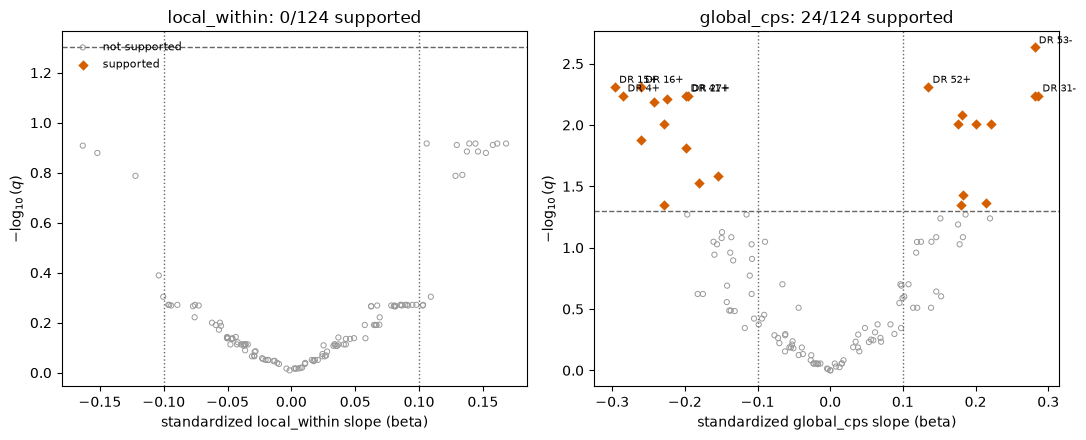

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
volcano_plot(axes[0], primary, "beta_local", "q_local", "supported_local", "local_within")
volcano_plot(axes[1], primary, "beta_global", "q_global", "supported_global", "global_cps")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()


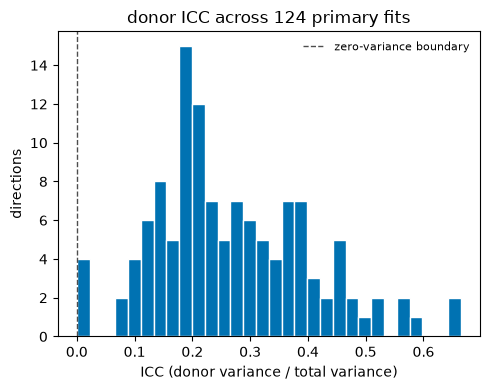

In [13]:
# How much of each direction's variance sits at the donor level? A direction with ICC
# near 0 has no random effect left (04_progression.ipynb's zero-variance boundary case),
# so its mixedlm p-value is effectively an OLS p-value -- worth seeing as a distribution,
# not just the boundary count already printed above.
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(primary["icc"], bins=30, color="#0072b2", edgecolor="white")
ax.axvline(1e-6, color="0.3", linestyle="--", linewidth=1, label="zero-variance boundary")
ax.set_xlabel("ICC (donor variance / total variance)")
ax.set_ylabel("directions")
ax.set_title(f"donor ICC across {len(primary)} primary fits")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## 3 — Regional heterogeneity

For `supported_local` directions: does the `local_within` slope differ by region? For
`supported_global` directions: does the `global_cps` slope differ by region? Both use a
nested likelihood-ratio test (`reml=False`, matching `05_mixed_models.ipynb`'s
`test_factor`); individual regional slopes are only reported when the omnibus test is
significant.


In [14]:
def heterogeneity_test(frame: pd.DataFrame, term: str) -> tuple[dict, pd.DataFrame]:
    '''Omnibus LRT for whether ``term``'s slope differs by region, plus per-region slopes.

    ``term`` is one of the two CPS regressors; the other stays as a shared covariate in
    both the reduced and full model so only the interaction of interest differs between
    them, which is what makes the comparison a valid nested-model LRT.
    '''
    other = "global_cps_z" if term == "local_within_z" else "local_within_z"
    # Term order matters for patsy's naming, not for the fitted values: writing
    # "C(region):term" (matching 05_mixed_models.ipynb's test_factor) names each
    # parameter "C(region)[X]:term", which the region-extraction below expects.
    full_formula = (
        f"activity_z ~ C(region):{term} + 0 + C(region) + {other} "
        "+ C(sex) + age_z + pmi_z + apoe_e4 + apoe_e2"
    )
    # `05_mixed_models.ipynb` uses `lbfgs` here, but on this model (region fixed effects
    # plus a region x CPS interaction) it silently collapses `donor_sd` to exactly 0 and
    # reports an infinite log-likelihood -- every one of the 24 real supported_global
    # directions hit this. `powell`/`cg`/`bfgs`/`nm` all agree closely and land away from
    # the boundary (checked directly before writing this), so `powell` is used for both
    # nested fits here, consistent with the boundary problem `04_progression.ipynb`
    # already documents for the primary (`reml=True`) fit.
    reduced_fit = fit_direction(frame, FORMULA, reml=False, method="powell")
    full_fit = fit_direction(frame, full_formula, reml=False, method="powell")
    lr_stat, lr_df, p = lrt(reduced_fit, full_fit)

    regional_rows = []
    for term_name in full_fit.fe_params.index:
        if term_name.endswith(f":{term}"):
            region = term_name.split("[", 1)[1].split("]", 1)[0]
            beta = full_fit.fe_params[term_name]
            se = full_fit.bse_fe[term_name]
            regional_rows.append({
                "region": region, "beta": beta, "se": se,
                "ci_low": beta - 1.96 * se, "ci_high": beta + 1.96 * se,
                "p": full_fit.pvalues[term_name],
            })
    overall = {
        "lr_stat": lr_stat, "lr_df": lr_df, "p": p,
        "reduced_converged": bool(reduced_fit.converged),
        "full_converged": bool(full_fit.converged),
    }
    return overall, pd.DataFrame(regional_rows)


In [15]:
def run_heterogeneity_family(term: str, supported_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    overall_rows, regional_rows = [], []
    for direction in primary.loc[primary[supported_col], "direction"]:
        frame = direction_frame(direction)
        overall, regional = heterogeneity_test(frame, term)
        overall["direction"] = direction
        regional["direction"] = direction
        overall_rows.append(overall)
        regional_rows.append(regional)
    overall_df = pd.DataFrame(overall_rows)
    if len(overall_df):
        overall_df["q"] = bh_correct(overall_df["p"].to_numpy(float))
    regional_df = pd.concat(regional_rows, ignore_index=True) if regional_rows else pd.DataFrame()
    return overall_df, regional_df


local_heterogeneity, local_heterogeneity_regional = run_heterogeneity_family(
    "local_within_z", "supported_local"
)
print(f"local x region heterogeneity tested for {len(local_heterogeneity)} supported directions")
if len(local_heterogeneity):
    print(f"  {(local_heterogeneity['q'] < Q_THRESHOLD).sum()} show significant regional heterogeneity")
local_heterogeneity.sort_values("p") if len(local_heterogeneity) else local_heterogeneity


local x region heterogeneity tested for 0 supported directions


""


In [16]:
global_heterogeneity, global_heterogeneity_regional = run_heterogeneity_family(
    "global_cps_z", "supported_global"
)
print(f"global x region heterogeneity tested for {len(global_heterogeneity)} supported directions")
if len(global_heterogeneity):
    print(f"  {(global_heterogeneity['q'] < Q_THRESHOLD).sum()} show significant regional heterogeneity")
global_heterogeneity.sort_values("p") if len(global_heterogeneity) else global_heterogeneity


global x region heterogeneity tested for 24 supported directions
  12 show significant regional heterogeneity


,lr_stat,lr_df,p,reduced_converged,full_converged,direction,q
20,50.781085,9,7.678508e-08,True,True,DR 53+,0.000002
12,35.151557,9,5.602472e-05,True,True,DR 39-,0.000672
6,33.153884,9,1.255583e-04,True,True,DR 22+,0.001004
3,27.031634,9,1.382013e-03,True,True,DR 16+,0.007658
21,26.653909,9,1.595464e-03,True,True,DR 53-,0.007658
17,25.890214,9,2.129205e-03,True,True,DR 48+,0.007660
0,25.762159,9,2.234227e-03,True,True,DR 4+,0.007660
1,23.932847,9,4.408751e-03,True,True,DR 10+,0.011860
15,23.909123,9,4.447322e-03,True,True,DR 47+,0.011860
23,21.493552,9,1.063037e-02,True,True,DR 56-,0.025513


In [17]:
# Only interpret individual regional slopes for directions whose omnibus test is
# significant -- everything else is a shared, non-heterogeneous slope by this test.
significant_local_directions = set(
    local_heterogeneity.loc[local_heterogeneity["q"] < Q_THRESHOLD, "direction"]
) if len(local_heterogeneity) else set()
local_heterogeneity_regional[
    local_heterogeneity_regional["direction"].isin(significant_local_directions)
] if len(local_heterogeneity_regional) else local_heterogeneity_regional


""


In [18]:
# Same filter for the global family (no equivalent cell existed above for it).
significant_global_directions = set(
    global_heterogeneity.loc[global_heterogeneity["q"] < Q_THRESHOLD, "direction"]
) if len(global_heterogeneity) else set()
global_heterogeneity_regional[
    global_heterogeneity_regional["direction"].isin(significant_global_directions)
] if len(global_heterogeneity_regional) else global_heterogeneity_regional


,region,beta,se,ci_low,ci_high,p,direction
0,AnG,-0.387111,0.109386,-0.601508,-0.172714,4.017409e-04,DR 4+
1,DFC,-0.182846,0.094427,-0.367923,0.002231,5.282254e-02,DR 4+
2,FI,-0.225489,0.112540,-0.446068,-0.004910,4.511004e-02,DR 4+
3,HIP,-0.235939,0.119222,-0.469615,-0.002264,4.781727e-02,DR 4+
4,ITG,-0.444618,0.109903,-0.660027,-0.229209,5.219737e-05,DR 4+
5,LEC,-0.113493,0.116178,-0.341202,0.114216,3.286226e-01,DR 4+
6,MEC,-0.264422,0.096081,-0.452741,-0.076104,5.921772e-03,DR 4+
7,MTG,-0.481926,0.094670,-0.667480,-0.296372,3.569996e-07,DR 4+
8,STG,-0.220918,0.110306,-0.437119,-0.004718,4.520207e-02,DR 4+
9,V1C,-0.135129,0.109246,-0.349252,0.078994,2.161164e-01,DR 4+


no omnibus-significant local_within directions to plot


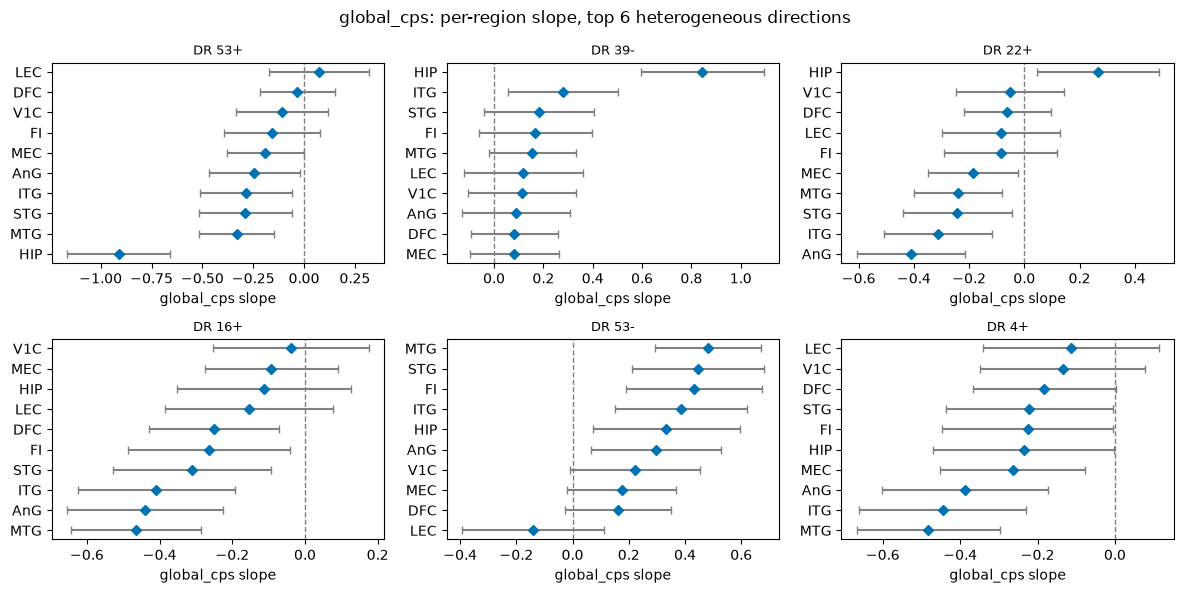

In [19]:
# Forest plots for the omnibus-significant directions in each family (capped at 6 per
# family so the grid stays readable) -- the table above already restricts to these, this
# just makes "which regions drive the heterogeneity" visible at a glance.
for heterogeneity_df, significant_directions, label in [
    (local_heterogeneity, significant_local_directions, "local_within"),
    (global_heterogeneity, significant_global_directions, "global_cps"),
]:
    if not significant_directions:
        print(f"no omnibus-significant {label} directions to plot")
        continue
    regional_df = local_heterogeneity_regional if label == "local_within" else global_heterogeneity_regional
    top_directions = (
        heterogeneity_df.loc[heterogeneity_df["direction"].isin(significant_directions)]
        .nsmallest(6, "q")["direction"]
        .tolist()
    )
    n_cols = 3
    n_rows = -(-len(top_directions) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
    for ax, direction in zip(axes.flat, top_directions):
        forest_plot(ax, regional_df, direction, label)
    for ax in axes.flat[len(top_directions):]:
        ax.axis("off")
    fig.suptitle(f"{label}: per-region slope, top {len(top_directions)} heterogeneous directions")
    fig.tight_layout()
    plt.show()


## 4 — Random-slope sensitivity

Sensitivity check on the `supported_local` directions: does an uncorrelated random
slope for `local_within_z` (`(1 + local_within_z || donor)`) change the picture?
statsmodels has no `||` syntax; the standard way to get the *uncorrelated* form is a
random intercept via `re_formula="1"` plus the slope as a `vc_formula` variance
component (which statsmodels always treats as independent of the other random
effects). Retained only where it converges, is non-singular, and improves AIC over the
random-intercept-only fit from section 2 -- otherwise the random-intercept model stays
primary, per the design.


In [20]:
median_regions = regions_per_donor.median()
print(f"median regions observed per donor: {median_regions:.0f} "
      f"({(regions_per_donor >= 3).sum()}/{len(regions_per_donor)} donors have >= 3)")


median regions observed per donor: 6 (79/84 donors have >= 3)


In [21]:
def random_slope_fit(frame: pd.DataFrame):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return smf.mixedlm(
            FORMULA, frame, groups=frame["donor"], re_formula="1",
            vc_formula={"local_within_slope": "0 + local_within_z"},
        ).fit(reml=True, method="powell")


random_slope_rows = []
for direction in primary.loc[primary["supported_local"], "direction"]:
    frame = direction_frame(direction)
    ri_fit = fit_direction(frame, FORMULA, reml=True, method="powell")
    try:
        rs_fit = random_slope_fit(frame)
    except Exception as exc:
        random_slope_rows.append({
            "direction": direction, "converged": False, "note": str(exc),
        })
        continue
    slope_var = float(rs_fit.vcomp[0]) if len(rs_fit.vcomp) else 0.0
    nonsingular = slope_var > 1e-6
    ri_aic = -2 * ri_fit.llf + 2 * (len(ri_fit.fe_params) + 1)
    rs_aic = -2 * rs_fit.llf + 2 * (len(rs_fit.fe_params) + 2)
    random_slope_rows.append({
        "direction": direction,
        "converged": bool(rs_fit.converged),
        "nonsingular": nonsingular,
        "slope_var": slope_var,
        "beta_local_ri": ri_fit.params["local_within_z"],
        "beta_local_rs": rs_fit.params["local_within_z"],
        "ri_aic": ri_aic,
        "rs_aic": rs_aic,
        "rs_improves_aic": rs_aic < ri_aic,
    })

random_slope = pd.DataFrame(random_slope_rows)
retained = random_slope.query("converged and nonsingular and rs_improves_aic") if len(random_slope) else random_slope
print(
    f"{len(retained)}/{len(random_slope)} supported directions retain a non-singular, "
    "converged, AIC-improving random slope; random-intercept stays primary for the rest"
)
random_slope


0/0 supported directions retain a non-singular, converged, AIC-improving random slope; random-intercept stays primary for the rest


""


## 5 — Amyloid and tau follow-up

Restricted to directions supported by composite CPS (`supported_local` or
`supported_global`). Builds donor-centered ABeta/pTau local-within terms and
donor-level-standardized ABeta/pTau global terms exactly as the composite versions were
built in section 1, fits them jointly, and tests the pTau-vs-ABeta contrasts the design
asks for.


In [22]:
for score, prefix in [("CPS_Local_ABeta", "abeta"), ("CPS_Local_pTau", "ptau")]:
    cohort[f"{prefix}_local_mean"] = cohort.groupby("donor")[score].transform("mean")
    within = cohort[score] - cohort[f"{prefix}_local_mean"]
    cohort[f"{prefix}_local_within_z"] = (within - within.mean()) / within.std()

for score, prefix in [("CPS_Global_ABeta", "abeta"), ("CPS_Global_pTau", "ptau")]:
    cohort[f"{prefix}_global_z"] = donor_level_standardize(cohort, score)

abeta_ptau_corr_local = cohort[["abeta_local_within_z", "ptau_local_within_z"]].corr().iloc[0, 1]
abeta_ptau_corr_global = (
    cohort.drop_duplicates("donor")[["abeta_global_z", "ptau_global_z"]].corr().iloc[0, 1]
)
print(f"corr(abeta, ptau) local-within: {abeta_ptau_corr_local:.3f}")
print(f"corr(abeta, ptau) global: {abeta_ptau_corr_global:.3f}")


corr(abeta, ptau) local-within: 0.562
corr(abeta, ptau) global: 0.694


In [23]:
JOINT_FORMULA = (
    "activity_z ~ abeta_local_within_z + ptau_local_within_z + abeta_global_z + ptau_global_z "
    "+ C(region) + C(sex) + age_z + pmi_z + apoe_e4 + apoe_e2"
)
ABETA_ONLY_FORMULA = (
    "activity_z ~ abeta_local_within_z + abeta_global_z "
    "+ C(region) + C(sex) + age_z + pmi_z + apoe_e4 + apoe_e2"
)
PTAU_ONLY_FORMULA = (
    "activity_z ~ ptau_local_within_z + ptau_global_z "
    "+ C(region) + C(sex) + age_z + pmi_z + apoe_e4 + apoe_e2"
)

composite_supported = sorted(
    set(primary.loc[primary["supported_local"], "direction"])
    | set(primary.loc[primary["supported_global"], "direction"])
)
print(f"{len(composite_supported)} directions supported by composite CPS; "
      "running the amyloid/tau follow-up on these")


24 directions supported by composite CPS; running the amyloid/tau follow-up on these


In [24]:
from patsy import dmatrix

pathology_rows = []
for direction in composite_supported:
    frame = direction_frame(direction)
    joint_fit = fit_direction(frame, JOINT_FORMULA, reml=True, method="powell")

    local_contrast = linear_contrast(joint_fit, "ptau_local_within_z", "abeta_local_within_z")
    global_contrast = linear_contrast(joint_fit, "ptau_global_z", "abeta_global_z")

    abeta_fit = fit_direction(frame, ABETA_ONLY_FORMULA, reml=True, method="powell")
    ptau_fit = fit_direction(frame, PTAU_ONLY_FORMULA, reml=True, method="powell")

    design = dmatrix(JOINT_FORMULA.split("~")[1], frame, return_type="dataframe")
    vif = {
        col: variance_inflation_factor(design.to_numpy(), design.columns.get_loc(col))
        for col in ["abeta_local_within_z", "ptau_local_within_z", "abeta_global_z", "ptau_global_z"]
    }

    pathology_rows.append({
        "direction": direction,
        "beta_abeta_local_joint": joint_fit.params["abeta_local_within_z"],
        "beta_ptau_local_joint": joint_fit.params["ptau_local_within_z"],
        "beta_abeta_local_solo": abeta_fit.params["abeta_local_within_z"],
        "beta_ptau_local_solo": ptau_fit.params["ptau_local_within_z"],
        "local_contrast_diff": float(local_contrast.effect[0]),
        "local_contrast_p": float(local_contrast.pvalue),
        "beta_abeta_global_joint": joint_fit.params["abeta_global_z"],
        "beta_ptau_global_joint": joint_fit.params["ptau_global_z"],
        "beta_abeta_global_solo": abeta_fit.params["abeta_global_z"],
        "beta_ptau_global_solo": ptau_fit.params["ptau_global_z"],
        "global_contrast_diff": float(global_contrast.effect[0]),
        "global_contrast_p": float(global_contrast.pvalue),
        "vif_abeta_local": vif["abeta_local_within_z"],
        "vif_ptau_local": vif["ptau_local_within_z"],
        "vif_abeta_global": vif["abeta_global_z"],
        "vif_ptau_global": vif["ptau_global_z"],
    })

pathology = pd.DataFrame(pathology_rows)
pathology


,direction,beta_abeta_local_joint,beta_ptau_local_joint,beta_abeta_local_solo,beta_ptau_local_solo,local_contrast_diff,local_contrast_p,beta_abeta_global_joint,beta_ptau_global_joint,beta_abeta_global_solo,beta_ptau_global_solo,global_contrast_diff,global_contrast_p,vif_abeta_local,vif_ptau_local,vif_abeta_global,vif_ptau_global
0,DR 10+,-0.076408,0.016481,-0.075006,-0.002404,0.092889,0.183745,0.146262,-0.357503,-0.090845,-0.268350,-0.503766,0.000278,2.005875,3.206905,2.796526,2.797129
1,DR 15+,0.023490,-0.053018,0.014737,-0.047429,-0.076508,0.291093,-0.039272,-0.282590,-0.222686,-0.306459,-0.243318,0.169194,2.005875,3.206905,2.796526,2.797129
2,DR 16+,-0.022556,-0.032316,-0.028907,-0.037506,-0.009759,0.892272,-0.062043,-0.220902,-0.205379,-0.260585,-0.158860,0.314283,2.005875,3.206905,2.796526,2.797129
3,DR 17-,0.025904,0.062098,0.035676,0.068636,0.036194,0.659498,-0.122479,0.356460,0.108572,0.279890,0.478939,0.007094,2.005875,3.206905,2.796526,2.797129
4,DR 21+,-0.038218,-0.007802,-0.041062,-0.017032,0.030415,0.688711,-0.030668,-0.217149,-0.171541,-0.237550,-0.186480,0.248277,2.005875,3.206905,2.796526,2.797129
5,DR 22+,-0.037807,-0.015503,-0.042401,-0.025286,0.022304,0.753934,0.046946,-0.212585,-0.095789,-0.183776,-0.259531,0.034760,2.005875,3.206905,2.796526,2.797129
6,DR 24-,-0.033904,-0.020592,-0.035340,-0.028900,0.013312,0.862249,0.008049,0.187611,0.130029,0.191690,0.179562,0.257301,2.005875,3.206905,2.796526,2.797129
7,DR 27+,0.030684,-0.066775,0.019251,-0.059201,-0.097459,0.151703,-0.029878,-0.182446,-0.153737,-0.200333,-0.152568,0.224580,2.005875,3.206905,2.796526,2.797129
8,DR 31+,-0.000875,0.014872,-0.000894,0.013930,0.015747,0.862045,0.128423,-0.389520,-0.127540,-0.307706,-0.517943,0.000880,2.005875,3.206905,2.796526,2.797129
9,DR 31-,-0.040099,0.025290,-0.035149,0.015813,0.065389,0.379229,-0.009411,0.321109,0.196857,0.314188,0.330520,0.069135,2.005875,3.206905,2.796526,2.797129


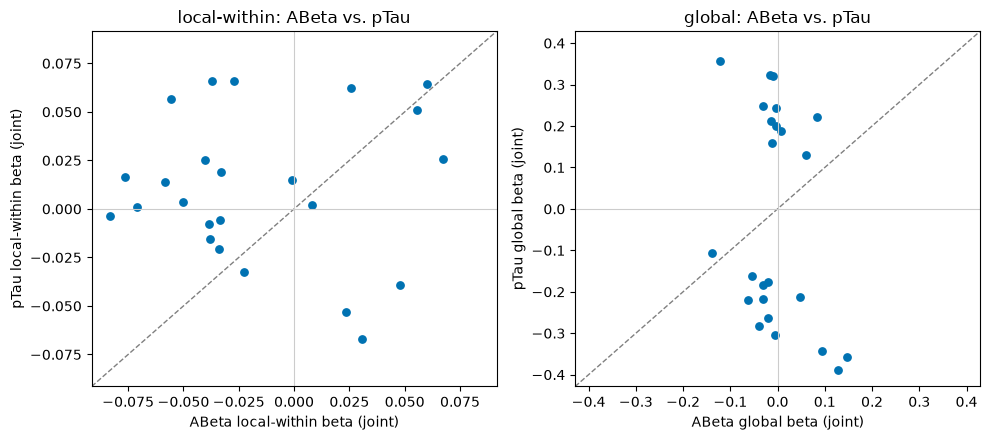

In [25]:
# ABeta vs pTau coefficients from the joint model -- visualizes the pTau-vs-ABeta
# contrasts tested above: a point off the diagonal is a direction where one pathology
# dominates, not the composite CPS split evenly between them.
if len(pathology):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, abeta_col, ptau_col, label in [
        (axes[0], "beta_abeta_local_joint", "beta_ptau_local_joint", "local-within"),
        (axes[1], "beta_abeta_global_joint", "beta_ptau_global_joint", "global"),
    ]:
        ax.scatter(pathology[abeta_col], pathology[ptau_col], s=28, color="#0072b2")
        lim = float(np.nanmax(np.abs(pathology[[abeta_col, ptau_col]].to_numpy()))) * 1.1
        ax.plot([-lim, lim], [-lim, lim], color="0.5", linestyle="--", linewidth=1)
        ax.axhline(0, color="0.8", linewidth=0.8)
        ax.axvline(0, color="0.8", linewidth=0.8)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_xlabel(f"ABeta {label} beta (joint)")
        ax.set_ylabel(f"pTau {label} beta (joint)")
        ax.set_title(f"{label}: ABeta vs. pTau")
    fig.tight_layout()
    plt.show()


In [26]:
# Donor-blocked CV: does ABeta, pTau, or the joint model predict held-out activity
# better? GroupKFold by donor, not a plain K-fold, since a donor's regions must not
# split across train/test. Held-out donors are new mixedlm groups, so `.predict()` here
# is a fixed-effects-only (population-average) prediction -- the right comparison for
# "which set of fixed-effect predictors generalizes across donors."
def cv_r2(frame: pd.DataFrame, formula: str, n_splits: int = 5) -> float:
    gkf = GroupKFold(n_splits=min(n_splits, frame["donor"].nunique()))
    r2s = []
    for train_idx, test_idx in gkf.split(frame, groups=frame["donor"]):
        train, test = frame.iloc[train_idx], frame.iloc[test_idx]
        fit = fit_direction(train, formula, reml=True, method="powell")
        pred = fit.predict(test)
        ss_res = float(((test["activity_z"].to_numpy() - pred.to_numpy()) ** 2).sum())
        ss_tot = float(((test["activity_z"].to_numpy() - train["activity_z"].mean()) ** 2).sum())
        if ss_tot > 0:
            r2s.append(1 - ss_res / ss_tot)
    return float(np.mean(r2s)) if r2s else np.nan


cv_rows = []
for direction in composite_supported:
    frame = direction_frame(direction)
    cv_rows.append({
        "direction": direction,
        "cv_r2_abeta": cv_r2(frame, ABETA_ONLY_FORMULA),
        "cv_r2_ptau": cv_r2(frame, PTAU_ONLY_FORMULA),
        "cv_r2_joint": cv_r2(frame, JOINT_FORMULA),
    })

pathology_cv = pd.DataFrame(cv_rows)
pathology_cv


,direction,cv_r2_abeta,cv_r2_ptau,cv_r2_joint
0,DR 10+,0.404927,0.419565,0.430918
1,DR 15+,0.268681,0.305402,0.299665
2,DR 16+,0.326658,0.341931,0.346541
3,DR 17-,0.133159,0.184681,0.167328
4,DR 21+,0.272143,0.279308,0.277033
5,DR 22+,0.429414,0.452793,0.447398
6,DR 24-,0.329388,0.343970,0.333299
7,DR 27+,0.473958,0.488261,0.484165
8,DR 31+,0.076195,0.151820,0.131878
9,DR 31-,0.207313,0.269724,0.250904


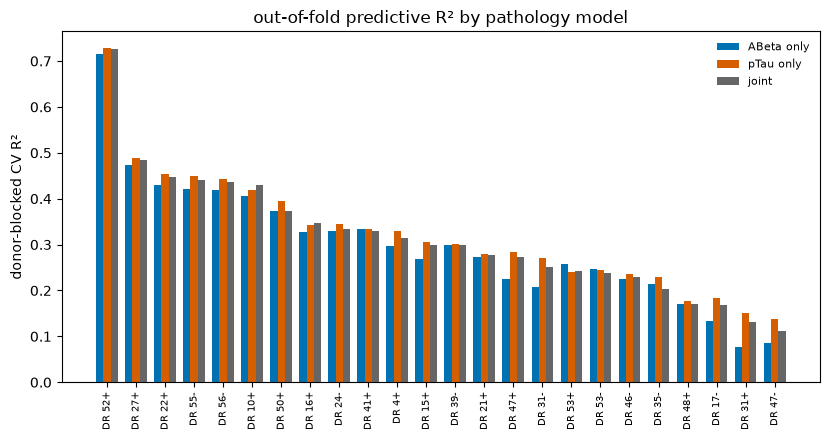

In [27]:
# Donor-blocked CV R^2 per direction, ABeta-only vs pTau-only vs joint -- the "does one
# predict better" question the design asks for, made visual rather than read off a table.
if len(pathology_cv):
    ordered = pathology_cv.sort_values("cv_r2_joint", ascending=False)
    x = np.arange(len(ordered))
    width = 0.25
    fig, ax = plt.subplots(figsize=(max(7, 0.35 * len(ordered)), 4.5))
    ax.bar(x - width, ordered["cv_r2_abeta"], width, label="ABeta only", color="#0072b2")
    ax.bar(x, ordered["cv_r2_ptau"], width, label="pTau only", color="#d55e00")
    ax.bar(x + width, ordered["cv_r2_joint"], width, label="joint", color="0.4")
    ax.axhline(0, color="0.7", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(ordered["direction"], rotation=90, fontsize=7)
    ax.set_ylabel("donor-blocked CV R²")
    ax.set_title("out-of-fold predictive R² by pathology model")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    plt.show()


## 6 — Robustness checks

Run across all live directions, per the analysis design. This is the most
compute-intensive section: the cluster bootstrap and leave-one-donor-out refits are
bounded with `joblib.Parallel` (`N_JOBS` workers) rather than scoped down to a subset of
directions.


In [28]:
def cluster_bootstrap_direction(direction: str, seed: int) -> dict:
    '''Empirical CI for beta_local/beta_global via a donor cluster bootstrap.

    Donors are resampled with replacement; a donor drawn twice must not be merged into
    one random-intercept group in the resample, or the resample's effective sample size
    would be inflated back toward the naive per-row count -- each draw gets a unique
    suffixed donor id.

    ``method="powell"`` despite ``reml=False``: checked directly on this data before
    writing this, ``lbfgs`` collapses `donor_sd` to exactly 0 on this formula (an
    "lbfgs finds the zero-variance boundary" case even sharper than the one
    `04_progression.ipynb` documents), which would make the bootstrap's point estimates
    an inconsistent mix of true-mixed-model and degenerate-OLS draws.
    '''
    frame = direction_frame(direction)
    rng = np.random.default_rng(seed)
    donors = frame["donor"].unique()
    betas_local, betas_global = [], []
    for b in range(N_BOOT):
        sample_donors = rng.choice(donors, size=len(donors), replace=True)
        parts = []
        for j, d in enumerate(sample_donors):
            part = frame[frame["donor"] == d].copy()
            part["donor"] = f"{d}__{j}"
            parts.append(part)
        boot_frame = pd.concat(parts, ignore_index=True)
        try:
            fit = fit_direction(boot_frame, FORMULA, reml=False, method="powell")
            betas_local.append(fit.params["local_within_z"])
            betas_global.append(fit.params["global_cps_z"])
        except Exception:
            continue
    betas_local, betas_global = np.array(betas_local), np.array(betas_global)
    return {
        "direction": direction,
        "n_boot_ok": len(betas_local),
        "boot_local_low": np.percentile(betas_local, 2.5) if len(betas_local) else np.nan,
        "boot_local_high": np.percentile(betas_local, 97.5) if len(betas_local) else np.nan,
        "boot_global_low": np.percentile(betas_global, 2.5) if len(betas_global) else np.nan,
        "boot_global_high": np.percentile(betas_global, 97.5) if len(betas_global) else np.nan,
    }


bootstrap_results = Parallel(n_jobs=N_JOBS)(
    delayed(cluster_bootstrap_direction)(direction, seed=RANDOM_STATE + i)
    for i, direction in enumerate(directions)
)
bootstrap = pd.DataFrame(bootstrap_results).merge(
    primary[["direction", "beta_local", "ci_local_low", "ci_local_high",
             "beta_global", "ci_global_low", "ci_global_high"]],
    on="direction",
)
bootstrap["local_ci_agrees"] = (
    (bootstrap["boot_local_low"] <= bootstrap["ci_local_high"])
    & (bootstrap["boot_local_high"] >= bootstrap["ci_local_low"])
)
bootstrap["global_ci_agrees"] = (
    (bootstrap["boot_global_low"] <= bootstrap["ci_global_high"])
    & (bootstrap["boot_global_high"] >= bootstrap["ci_global_low"])
)
print(f"local CI agreement (Wald vs. cluster bootstrap): "
      f"{bootstrap['local_ci_agrees'].mean():.1%} of directions")
print(f"global CI agreement (Wald vs. cluster bootstrap): "
      f"{bootstrap['global_ci_agrees'].mean():.1%} of directions")
bootstrap.loc[~(bootstrap["local_ci_agrees"] & bootstrap["global_ci_agrees"])]


local CI agreement (Wald vs. cluster bootstrap): 100.0% of directions
global CI agreement (Wald vs. cluster bootstrap): 100.0% of directions


,direction,n_boot_ok,boot_local_low,boot_local_high,boot_global_low,boot_global_high,beta_local,ci_local_low,ci_local_high,beta_global,ci_global_low,ci_global_high,local_ci_agrees,global_ci_agrees


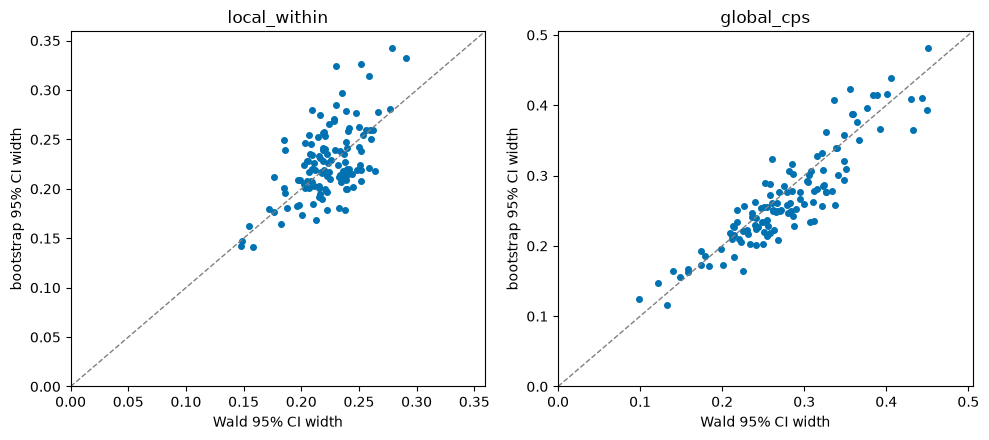

In [29]:
# Wald vs. cluster-bootstrap CI width, per direction -- the agreement percentages above
# say whether the intervals overlap; this shows whether one is systematically wider.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, wald_lo, wald_hi, boot_lo, boot_hi, label in [
    (axes[0], "ci_local_low", "ci_local_high", "boot_local_low", "boot_local_high", "local_within"),
    (axes[1], "ci_global_low", "ci_global_high", "boot_global_low", "boot_global_high", "global_cps"),
]:
    wald_width = bootstrap[wald_hi] - bootstrap[wald_lo]
    boot_width = bootstrap[boot_hi] - bootstrap[boot_lo]
    ax.scatter(wald_width, boot_width, s=16, color="#0072b2")
    lim = float(np.nanmax([wald_width.max(), boot_width.max()])) * 1.05
    ax.plot([0, lim], [0, lim], color="0.5", linestyle="--", linewidth=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Wald 95% CI width")
    ax.set_ylabel("bootstrap 95% CI width")
    ax.set_title(label)
fig.tight_layout()
plt.show()


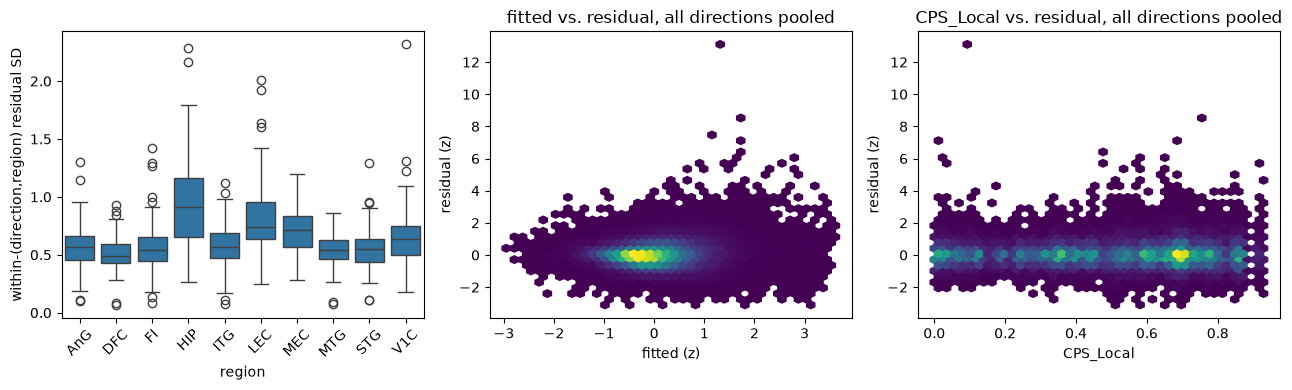

In [30]:
# Residual diagnostics, aggregated rather than one figure per direction (124 of them).
residual_long["sq_resid"] = residual_long["resid"] ** 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

region_sd = residual_long.groupby(["direction", "region"])["resid"].std().reset_index()
sns.boxplot(data=region_sd, x="region", y="resid", ax=axes[0])
axes[0].set_ylabel("within-(direction,region) residual SD")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hexbin(residual_long["fitted"], residual_long["resid"], gridsize=40, mincnt=1)
axes[1].set_xlabel("fitted (z)")
axes[1].set_ylabel("residual (z)")
axes[1].set_title("fitted vs. residual, all directions pooled")

axes[2].hexbin(residual_long["CPS_Local"], residual_long["resid"], gridsize=40, mincnt=1)
axes[2].set_xlabel("CPS_Local")
axes[2].set_ylabel("residual (z)")
axes[2].set_title("CPS_Local vs. residual, all directions pooled")

fig.tight_layout()
plt.show()


In [31]:
def lodo_direction(direction: str) -> dict:
    '''Max shift in beta_local/beta_global across all single-donor-deletion refits.

    ``powell`` for the same reason as the bootstrap above -- ``lbfgs`` collapses to the
    zero-variance boundary on this formula.
    '''
    frame = direction_frame(direction)
    base_fit = fit_direction(frame, FORMULA, reml=False, method="powell")
    base_local = base_fit.params["local_within_z"]
    base_global = base_fit.params["global_cps_z"]
    max_shift_local = max_shift_global = 0.0
    worst_donor = None
    for d in frame["donor"].unique():
        sub = frame[frame["donor"] != d]
        try:
            fit = fit_direction(sub, FORMULA, reml=False, method="powell")
        except Exception:
            continue
        shift_local = abs(fit.params["local_within_z"] - base_local)
        shift_global = abs(fit.params["global_cps_z"] - base_global)
        if shift_local > max_shift_local:
            max_shift_local = shift_local
            worst_donor = d
        max_shift_global = max(max_shift_global, shift_global)
    return {
        "direction": direction,
        "base_beta_local": base_local,
        "max_shift_local": max_shift_local,
        "max_shift_global": max_shift_global,
        "most_influential_donor": worst_donor,
    }


lodo_results = Parallel(n_jobs=N_JOBS)(delayed(lodo_direction)(d) for d in directions)
lodo = pd.DataFrame(lodo_results)
# Flag a direction as donor-fragile if deleting one donor moves beta_local by more than
# the practical effect threshold used to call the direction "supported" in the first place.
lodo["fragile_local"] = lodo["max_shift_local"] > EFFECT_THRESHOLD
print(f"{lodo['fragile_local'].sum()}/{len(lodo)} directions have a single donor whose "
      f"removal shifts beta_local by more than {EFFECT_THRESHOLD}")
lodo.sort_values("max_shift_local", ascending=False).head(15)


0/124 directions have a single donor whose removal shifts beta_local by more than 0.1


,direction,base_beta_local,max_shift_local,max_shift_global,most_influential_donor,fragile_local
114,DR 58+,-0.030339,0.070973,0.035565,H21.33.002,False
12,DR 7+,-0.096736,0.069987,0.044473,H21.33.001,False
36,DR 19+,0.047646,0.061351,0.024012,H20.33.027,False
110,DR 56+,0.091038,0.054530,0.036392,H20.33.020,False
113,DR 57-,-0.021458,0.052925,0.035419,H21.33.001,False
37,DR 19-,-0.016626,0.046306,0.036557,H20.33.027,False
49,DR 25-,-0.060989,0.042242,0.041695,H21.33.033,False
84,DR 43+,-0.031817,0.042062,0.022285,H21.33.018,False
65,DR 33-,-0.151133,0.041334,0.035772,H20.33.020,False
14,DR 8+,0.017561,0.039274,0.014312,H20.33.020,False


In [32]:
# Gaussian vs. robust (Huber) fixed-effects fit, for leading directions only -- the
# design scopes this specific check to "leading directions", unlike the rest of this
# section. statsmodels' MixedLM has no Student-t option, so this is an approximate,
# donor-clustering-ignoring diagnostic (documented as such, not a substitute for the
# primary mixed model): if a Huber fit and an OLS fit on the same fixed-effect design
# disagree sharply, a handful of outlying donor-region observations are worth a look.
leading_directions = (
    primary.loc[primary["supported_local"] | primary["supported_global"]]
    .assign(min_p=lambda d: d[["p_local", "p_global"]].min(axis=1))
    .nsmallest(10, "min_p")["direction"]
)

robust_rows = []
for direction in leading_directions:
    frame = direction_frame(direction)
    design = dmatrix(FORMULA.split("~")[1], frame, return_type="dataframe")
    y = frame["activity_z"].to_numpy()
    ols_fit = OLS(y, design).fit()
    rlm_fit = RLM(y, design).fit()
    robust_rows.append({
        "direction": direction,
        "beta_local_ols": ols_fit.params["local_within_z"],
        "beta_local_huber": rlm_fit.params["local_within_z"],
        "beta_global_ols": ols_fit.params["global_cps_z"],
        "beta_global_huber": rlm_fit.params["global_cps_z"],
    })

robust_comparison = pd.DataFrame(robust_rows)
robust_comparison


,direction,beta_local_ols,beta_local_huber,beta_global_ols,beta_global_huber
0,DR 53-,0.043745,0.086874,0.287769,0.251445
1,DR 16+,-0.088465,-0.122562,-0.266400,-0.232255
2,DR 15+,-0.083653,-0.077320,-0.273095,-0.274995
3,DR 52+,0.052636,0.069809,0.134297,0.110212
4,DR 27+,-0.053282,-0.068174,-0.178250,-0.158817
5,DR 41+,0.063536,-0.004474,-0.185997,-0.182521
6,DR 4+,-0.089414,-0.104379,-0.273967,-0.266219
7,DR 31-,0.034633,0.063428,0.291067,0.247186
8,DR 47+,0.003251,0.039572,0.288523,0.205697
9,DR 53+,0.073410,0.020894,-0.226211,-0.224890


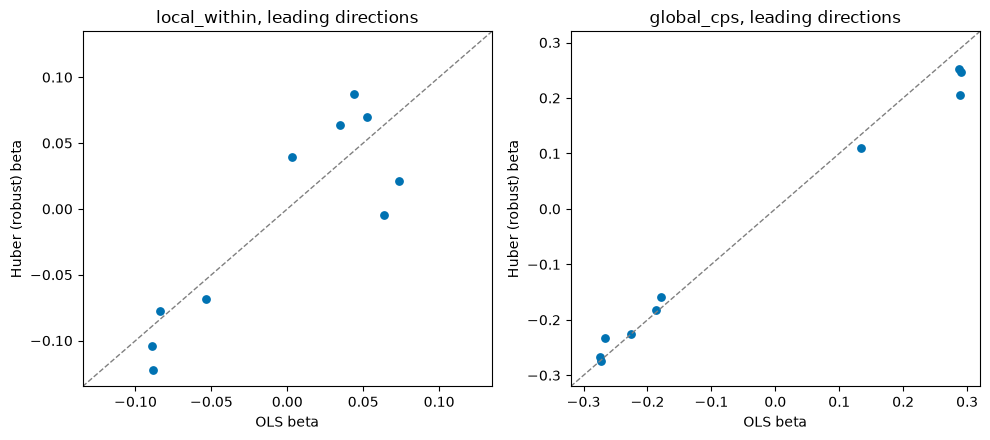

In [33]:
# OLS vs. Huber beta for the leading directions -- a point off the diagonal means a
# handful of outlying donor-region observations are pulling the Gaussian fit around.
if len(robust_comparison):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, ols_col, huber_col, label in [
        (axes[0], "beta_local_ols", "beta_local_huber", "local_within"),
        (axes[1], "beta_global_ols", "beta_global_huber", "global_cps"),
    ]:
        ax.scatter(robust_comparison[ols_col], robust_comparison[huber_col], s=28, color="#0072b2")
        lim = float(np.nanmax(np.abs(robust_comparison[[ols_col, huber_col]].to_numpy()))) * 1.1
        ax.plot([-lim, lim], [-lim, lim], color="0.5", linestyle="--", linewidth=1)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_xlabel("OLS beta")
        ax.set_ylabel("Huber (robust) beta")
        ax.set_title(f"{label}, leading directions")
    fig.tight_layout()
    plt.show()


In [34]:
# Does pseudobulk cell count leave a mark on residual variance? Spearman on the pooled
# residuals from every direction's section-2 fit, since a monotone-but-nonlinear
# relationship (noisier at low n_cells) is more likely than a linear one here.
rho, p = stats.spearmanr(residual_long["n_cells"], residual_long["sq_resid"])
print(f"Spearman(n_cells, squared residual), pooled across all directions: "
      f"rho={rho:.3f}, p={p:.2e}")


Spearman(n_cells, squared residual), pooled across all directions: rho=-0.153, p=0.00e+00


## 7 — Summary

Two outputs per direction: an overall donor-level disease association (`beta_global`)
and a genuinely regional, within-donor pathology association (`beta_local`), each with
its own FDR family, its own regional-heterogeneity check, and (for the composite-CPS
hits) an ABeta/pTau decomposition.


In [35]:
both_supported = primary["supported_local"] & primary["supported_global"]
print(f"{len(primary)} live directions tested")
print(f"  {primary['supported_local'].sum()} supported for local_within (regional excess pathology)")
print(f"  {primary['supported_global'].sum()} supported for global_cps (overall donor burden)")
print(f"  {both_supported.sum()} supported for both")
if len(local_heterogeneity):
    print(f"  {(local_heterogeneity['q'] < Q_THRESHOLD).sum()}/{len(local_heterogeneity)} "
          "local-supported directions show significant region x local_within heterogeneity")
if len(global_heterogeneity):
    print(f"  {(global_heterogeneity['q'] < Q_THRESHOLD).sum()}/{len(global_heterogeneity)} "
          "global-supported directions show significant region x global_cps heterogeneity")
print(f"  {len(composite_supported)} directions carried into the amyloid/tau follow-up")
print(f"  {int(lodo['fragile_local'].sum())} directions flagged donor-fragile by leave-one-donor-out")


124 live directions tested
  0 supported for local_within (regional excess pathology)
  24 supported for global_cps (overall donor burden)
  0 supported for both
  12/24 global-supported directions show significant region x global_cps heterogeneity
  24 directions carried into the amyloid/tau follow-up
  0 directions flagged donor-fragile by leave-one-donor-out


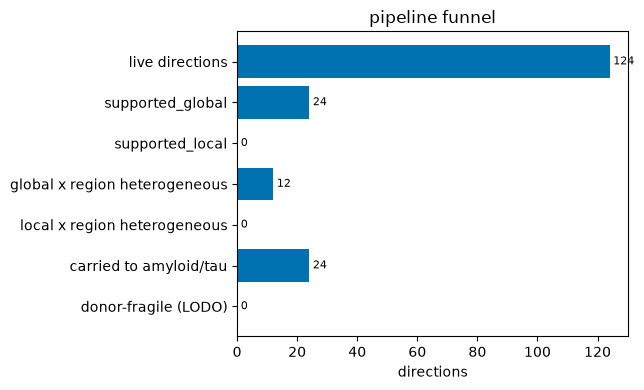

In [36]:
# One picture for the counts just printed.
funnel = [
    ("live directions", len(primary)),
    ("supported_global", int(primary["supported_global"].sum())),
    ("supported_local", int(primary["supported_local"].sum())),
    ("global x region heterogeneous", int((global_heterogeneity["q"] < Q_THRESHOLD).sum()) if len(global_heterogeneity) else 0),
    ("local x region heterogeneous", int((local_heterogeneity["q"] < Q_THRESHOLD).sum()) if len(local_heterogeneity) else 0),
    ("carried to amyloid/tau", len(composite_supported)),
    ("donor-fragile (LODO)", int(lodo["fragile_local"].sum())),
]
labels, values = zip(*funnel)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.barh(labels[::-1], values[::-1], color="#0072b2")
for i, v in enumerate(values[::-1]):
    ax.text(v + max(values) * 0.01, i, str(v), va="center", fontsize=8)
ax.set_xlabel("directions")
ax.set_title("pipeline funnel")
fig.tight_layout()
plt.show()


In [37]:
# Cache results for downstream notebooks (mirrors the write-once-read-downstream
# pattern 03_pseudobulk/04_progression/archive/06_hierarchical_bayes already use).
# `09_annotate_cps_hits.ipynb` reads these to annotate the supported directions
# without re-fitting anything here.
primary.to_parquet(PSEUDO_DIR / "cps_mixed_models_primary.parquet", index=False)
local_heterogeneity.to_parquet(PSEUDO_DIR / "cps_mixed_models_local_heterogeneity.parquet", index=False)
local_heterogeneity_regional.to_parquet(PSEUDO_DIR / "cps_mixed_models_local_heterogeneity_regional.parquet", index=False)
global_heterogeneity.to_parquet(PSEUDO_DIR / "cps_mixed_models_global_heterogeneity.parquet", index=False)
global_heterogeneity_regional.to_parquet(PSEUDO_DIR / "cps_mixed_models_global_heterogeneity_regional.parquet", index=False)
pathology.to_parquet(PSEUDO_DIR / "cps_mixed_models_pathology.parquet", index=False)
print(f"cached primary/heterogeneity/pathology tables to {PSEUDO_DIR}")


cached primary/heterogeneity/pathology tables to /scratch/sst-drvi/pseudobulk
